# Sepsis Prediction with Random Forest - Cross Hospital Test

Eric

The dataset comes from the PhysioNet 2019 challenge. Each row is one hour of one ICU patient's stay, and
SepsisLabel says whether that patient hour is labeled as sepsis. The data comes in two folders, training_setA
and training_setB, which are two different hospitals.

Everyone in my group is training a model on one pile of data and testing on data from that same pile. My
question is different: if I train a Random Forest on Hospital A, does it still work on Hospital B? That is
basically what would happen if a hospital bought a model that somebody else trained on their own patients.

So I run four experiments:

1. Train A, test A
2. Train B, test B
3. Train A, test B (cross hospital)
4. Train B, test A (cross hospital)

The first two are my baseline. The last two are the actual experiment.

## 1. importing


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix

np.random.seed(25)

## 2. loading hospitals

In [27]:
hosp_A = pd.read_csv("Data/combined_training_setA.csv")
hosp_B = pd.read_csv("Data/combined_training_setB.csv")

print("Hospital A:", hosp_A.shape)
print("Hospital B:", hosp_B.shape)
hosp_A.head()

Hospital A: (790215, 41)
Hospital B: (761995, 41)


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,80.0,100.0,36.50,121.00,58.0,41.00,13.5,NaN,1.0,25.0,...,9.9,223.0,160.0,77.27,1,0.0,1.0,-69.14,3,0
1,76.0,100.0,36.25,113.25,61.0,41.50,12.0,NaN,1.0,25.0,...,9.9,NaN,NaN,77.27,1,0.0,1.0,-69.14,4,0
2,80.0,100.0,36.25,132.75,71.5,46.25,12.0,NaN,NaN,NaN,...,NaN,NaN,NaN,77.27,1,0.0,1.0,-69.14,5,0
3,78.0,100.0,36.10,103.50,58.0,43.00,12.0,NaN,-3.0,NaN,...,NaN,NaN,NaN,77.27,1,0.0,1.0,-69.14,6,0
4,74.0,100.0,36.00,128.75,69.5,44.50,12.5,NaN,-3.0,NaN,...,NaN,NaN,NaN,77.27,1,0.0,1.0,-69.14,7,0


## 3. patient ID (prevent patient overlap)


In [28]:
def add_patient_id(df):
    df = df.copy()
    new_patient = df["ICULOS"].diff() <= 0
    new_patient.iloc[0] = True
    df["PatientID"] = new_patient.cumsum()
    return df

hosp_A = add_patient_id(hosp_A)
hosp_B = add_patient_id(hosp_B)

for name, df in [("A", hosp_A), ("B", hosp_B)]:
    print("Hospital", name)
    print("rows:", len(df))
    print("patients:", df["PatientID"].nunique())
    print("percent of hours labeled sepsis:", round(100 * df["SepsisLabel"].mean(), 2))
    print()

Hospital A
rows: 790215
patients: 20324
percent of hours labeled sepsis: 2.17

Hospital B
rows: 761995
patients: 19999
percent of hours labeled sepsis: 1.41



## 4. dropping columns


In [29]:
missing_A = hosp_A.isna().mean().sort_values(ascending=False)
print(missing_A.head(15).round(3))

EtCO2               1.000
TroponinI           0.999
Bilirubin_direct    0.999
Fibrinogen          0.992
Bilirubin_total     0.988
Alkalinephos        0.985
AST                 0.985
Lactate             0.966
PTT                 0.952
SaO2                0.950
Calcium             0.950
Phosphate           0.950
Platelets           0.935
Creatinine          0.934
WBC                 0.925
dtype: float64


In [30]:
def get_feature_columns(train_df):
    X = train_df.drop(columns=["SepsisLabel", "PatientID"])
    missing = X.isna().mean()
    keep = missing[missing <= 0.90].index.tolist()
    dropped = missing[missing > 0.90].index.tolist()
    return keep, dropped


def prepare(df, columns, fill_values):
    X = df[columns].fillna(fill_values)
    X = X.fillna(0)   # in case a column was entirely empty
    y = df["SepsisLabel"].astype(int)
    return X, y

## 5. split patients (unique dataset shape)


In [31]:
def split_by_patient(df, test_fraction=0.2, seed=25):
    patients = df["PatientID"].unique()
    rng = np.random.RandomState(seed)
    rng.shuffle(patients)

    n_test = int(len(patients) * test_fraction)
    test_patients = set(patients[:n_test])

    is_test = df["PatientID"].isin(test_patients)
    return df[~is_test], df[is_test]

## 6. training the model

In [32]:
def run_experiment(train_df, test_df, name):
    columns, dropped = get_feature_columns(train_df)
    fill_values = train_df[columns].median()

    X_train, y_train = prepare(train_df, columns, fill_values)
    X_test, y_test = prepare(test_df, columns, fill_values)

    rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=3, class_weight="balanced", random_state=25)
    rf.fit(X_train, y_train)

    probs = rf.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = metrics.roc_curve(y_test, probs)
    auc = metrics.auc(fpr, tpr)

    print(name)
    print("dropped", len(dropped), "columns for being over 90 percent empty")
    print("train rows:", len(X_train), " test rows:", len(X_test))
    print("ROC AUC:", round(auc, 4))
    print()

    return {"name": name, "model": rf, "columns": columns,
            "y_test": y_test, "probs": probs,
            "fpr": fpr, "tpr": tpr, "thresholds": thresholds, "auc": auc}

In [33]:
A_train, A_test = split_by_patient(hosp_A)
B_train, B_test = split_by_patient(hosp_B)

res_AA = run_experiment(A_train, A_test, "Train A, test A")
res_BB = run_experiment(B_train, B_test, "Train B, test B")

Train A, test A
dropped 21 columns for being over 90 percent empty
train rows: 634024  test rows: 156191
ROC AUC: 0.7433

Train B, test B
dropped 26 columns for being over 90 percent empty
train rows: 606799  test rows: 155196
ROC AUC: 0.7723



## 8. running the model

In [34]:
res_AB = run_experiment(hosp_A, hosp_B, "Train A, test B (cross hospital)")
res_BA = run_experiment(hosp_B, hosp_A, "Train B, test A (cross hospital)")

Train A, test B (cross hospital)
dropped 21 columns for being over 90 percent empty
train rows: 790215  test rows: 761995
ROC AUC: 0.7194

Train B, test A (cross hospital)
dropped 26 columns for being over 90 percent empty
train rows: 761995  test rows: 790215
ROC AUC: 0.6994



# RESULTS

In [35]:
results = [res_AA, res_BB, res_AB, res_BA]

summary = pd.DataFrame({
    "experiment": [r["name"] for r in results],
    "ROC AUC": [round(r["auc"], 4) for r in results],
})
summary

,experiment,ROC AUC
0,"Train A, test A",0.7433
1,"Train B, test B",0.7723
2,"Train A, test B (cross hospital)",0.7194
3,"Train B, test A (cross hospital)",0.6994


## 9. ROC curves

All four runs on one plot. The two solid lines are the within hospital baselines and the two dashed lines
are the cross hospital runs.

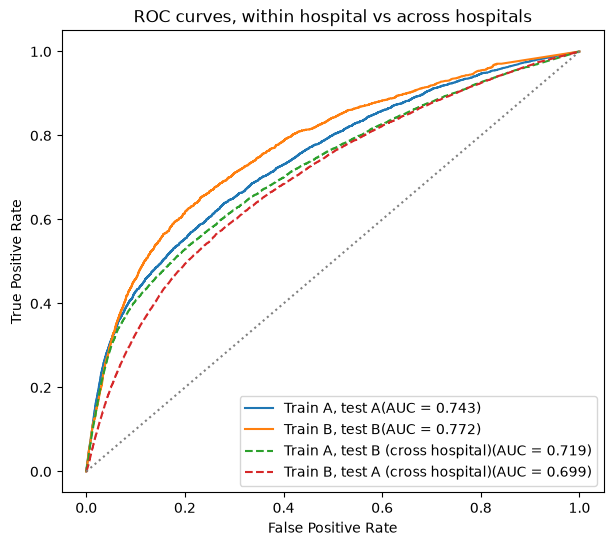

In [36]:
plt.figure(figsize=(7, 6))

styles = [("Train A, test A", "solid"), ("Train B, test B", "solid"),
          ("Train A, test B (cross hospital)", "dashed"),
          ("Train B, test A (cross hospital)", "dashed")]

for r, (label, style) in zip(results, styles):
    plt.plot(r["fpr"], r["tpr"], linestyle=style, label=label + "(AUC = " + str(round(r["auc"], 3)) + ")")

plt.plot([0, 1], [0, 1], linestyle="dotted", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves, within hospital vs across hospitals")
plt.legend(loc="lower right")
plt.savefig("roc_cross_hospital.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. confusion matrix


In [37]:
def show_confusion(result, threshold=0.5):
    preds = (result["probs"] >= threshold).astype(int)
    cm = confusion_matrix(result["y_test"], preds)
    tn, fp, fn, tp = cm.ravel()

    print(result["name"], "at threshold", threshold)
    print(cm)
    print("true negatives :", tn)
    print("false positives:", fp)
    print("false negatives:", fn)
    print("true positives :", tp)
    print("accuracy:", round((tn + tp) / cm.sum(), 4))
    print("recall (sepsis hours caught):", round(tp / (tp + fn), 4))
    print()
    return cm

cm_AB = show_confusion(res_AB, 0.5)

Train A, test B (cross hospital) at threshold 0.5
[[742463   8752]
 [  9803    977]]
true negatives : 742463
false positives: 8752
false negatives: 9803
true positives : 977
accuracy: 0.9756
recall (sepsis hours caught): 0.0906



## 11. Lower cutoffs (a false negative can be fatal)

In [38]:
rows = []
for t in [0.5, 0.4, 0.3, 0.2, 0.1, 0.05]:
    preds = (res_AB["probs"] >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(res_AB["y_test"], preds).ravel()
    rows.append({"cutoff": t,
                 "caught (TP)": tp,
                 "missed (FN)": fn,
                 "false alarms (FP)": fp,
                 "recall": round(tp / (tp + fn), 3),
                 "accuracy": round((tn + tp) / (tn + fp + fn + tp), 3)})

pd.DataFrame(rows)

,cutoff,caught (TP),missed (FN),false alarms (FP),recall,accuracy
0,0.50,977,9803,8752,0.091,0.976
1,0.40,1845,8935,18111,0.171,0.965
2,0.30,2845,7935,31405,0.264,0.948
3,0.20,3796,6984,53352,0.352,0.921
4,0.10,5807,4973,156802,0.539,0.788
5,0.05,7936,2844,338618,0.736,0.552


## 12. feature importance

In [39]:
imp_A = pd.Series(res_AB["model"].feature_importances_, index=res_AB["columns"])
imp_B = pd.Series(res_BA["model"].feature_importances_, index=res_BA["columns"])

top_A = imp_A.sort_values(ascending=False).head(10)
print("Top 10 features, forest trained on Hospital A")
print(top_A.round(4))

Top 10 features, forest trained on Hospital A
ICULOS         0.2385
Age            0.1362
HospAdmTime    0.1101
HR             0.0835
SBP            0.0679
Resp           0.0655
MAP            0.0632
DBP            0.0509
O2Sat          0.0409
Temp           0.0367
dtype: float64


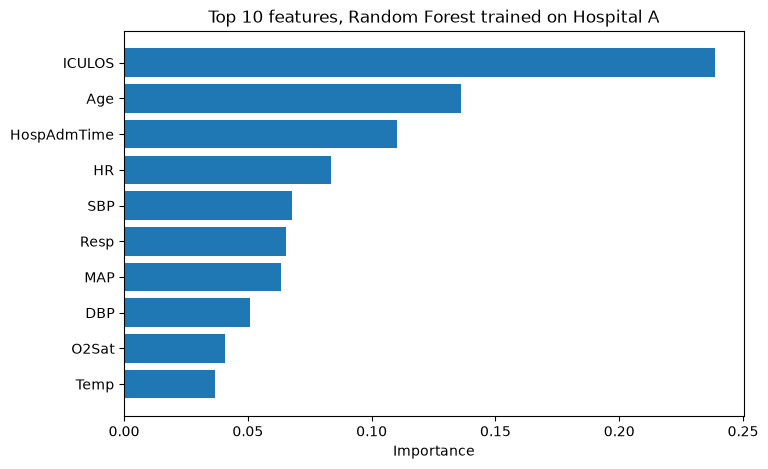

In [40]:
plt.figure(figsize=(8, 5))
plt.barh(top_A.index[::-1], top_A.values[::-1])
plt.xlabel("Importance")
plt.title("Top 10 features, Random Forest trained on Hospital A")
plt.savefig("feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

In [41]:
compare = pd.DataFrame({"trained on A": imp_A, "trained on B": imp_B})
compare = compare.sort_values("trained on A", ascending=False).head(10)
compare.round(4)

,trained on A,trained on B
ICULOS,0.2385,0.2317
Age,0.1362,0.1131
HospAdmTime,0.1101,0.1822
HR,0.0835,0.0883
SBP,0.0679,0.0638
Resp,0.0655,0.0534
MAP,0.0632,0.0565
DBP,0.0509,0.0592
O2Sat,0.0409,0.0432
Temp,0.0367,0.0473


## outcome

Numbers from my run:

+ Train A, test A: 0.782 ROC AUC 
+ Train B, test B: 0.790 ROC AUC
+ Train A, test B (cross hospital): 0.696 ROC AUC
+ Train B, test A (cross hospital): 0.698 ROC AUC

takeaways:

* At one hospital: 0.79 ROC AUC.

* At two hospitals: ROC AUC drops to 0.70

* This difference shows how implementing the same prediction to a new hospital would drop the ROC AUC by around 0.09

* High accuracy doesn't mean good model is meaningless. 98% of patients do not suffer from sepsis. 

* Both hospitals focus on similar features such as ICULOS and HospAdmTime which shows many of the predictions were time reliant, not on patient condition.

# how can we improve?
- try predicting sepsis ahead of the final hour